In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import butter, sosfiltfilt, welch
from scipy.signal import windows as scipy_windows
from scipy.stats import kurtosis, skew, anderson
import pandas as pd

print("All imports OK")

All imports OK


In [ ]:

df = pd.read_csv('/content/H1_O3a.csv')   #filename after download

#Filter for H1 only, O3a time range, and a specific glitch type
mask = (
    (df['ifo'] == 'H1') &
    (df['peak_time'] > 1238166018) &
    (df['peak_time'] < 1253977218) &
    (df['ml_label'] == 'Blip') &
    (df['ml_confidence'] > 0.95)
)

blips = df[mask].reset_index(drop=True)
print(f"Found {len(blips)} blip glitches in H1 O3a")
print(blips[['peak_time', 'snr', 'peak_frequency']].head(10))

#GPS time of the first one
glitch_gps = blips['peak_time'].iloc[0]
print(f"\nFirst blip GPS: {glitch_gps}")

Found 3672 blip glitches in H1 O3a
    peak_time        snr  peak_frequency
0  1238613687  50.885971      262.064606
1  1253281176  53.985920      269.284821
2  1253525595  20.051600      142.362854
3  1253516704  62.397282      411.865448
4  1253417416  29.159430      269.284821
5  1252801507  46.583160      217.740967
6  1253509308   8.957610      115.113152
7  1253530799   8.799940      115.113152
8  1253369770  17.634050      411.865448
9  1253541134   9.527580      176.063126

First blip GPS: 1238613687


In [ ]:
#find valid glitch GPS time from catalogue
from gwosc.timeline import get_segments

GLITCH_TYPE = 'Blip'   # ← change to any ml_label value: 'Scattered_Light', 'Koi_Fish', etc.
MIN_CONFIDENCE = 0.95
MIN_SNR = 10

#filter catalogue
candidates = df[
    (df['ifo'] == 'H1') &
    (df['peak_time'] > 1238166018) &
    (df['peak_time'] < 1253977218) &
    (df['ml_label'] == GLITCH_TYPE) &
    (df['ml_confidence'] > MIN_CONFIDENCE) &
    (df['snr'] > MIN_SNR)
].sort_values('ml_confidence', ascending=False).reset_index(drop=True)

print(f"Candidates ({GLITCH_TYPE}, confidence>{MIN_CONFIDENCE}, SNR>{MIN_SNR}): {len(candidates)}")

#ind first one with available data
glitch_gps = None
for _, row in candidates.iterrows():
    t = int(row['peak_time'])
    try:
        segs = get_segments('H1_DATA', t - 5, t + 5)
        if segs:
            glitch_gps = t
            print(f"\nFound valid GPS : {glitch_gps}")
            print(f"SNR             : {row['snr']:.1f}")
            print(f"Peak frequency  : {row['peak_frequency']:.1f} Hz")
            print(f"Confidence      : {row['ml_confidence']:.4f}")
            print(f"Duration        : {row['duration']:.3f} s")
            break
    except Exception:
        continue

if glitch_gps is None:
    print("No valid GPS found — try lowering MIN_CONFIDENCE or MIN_SNR")

Candidates (Blip, confidence>0.95, SNR>10): 2540

Found valid GPS : 1240595566
SNR             : 14.3
Peak frequency  : 324.8 Hz
Confidence      : 1.0000
Duration        : 0.078 s


In [ ]:
#Modes
# Change MODE to switch between the event segment and a glitch segment
#'event'  — uses txt file
#'glitch' — fetches a short segment around a specific glitch GPS time

MODE = 'glitch'   #change to 'glitch' or 'event'

#event mode config
FILENAME  = 'H-H1_GWOSC_O3a_4KHZ_R1-1242442952-32.txt'
fs_event  = 4096
gps_start = 1242442952
EVENT     = 'GW190521'
DETECTOR  = 'H1'

#Glitch mode config
#GPS times from the GravitySpy/Omicron catalogue (zenodo.org/records/5649212)
GLITCH_CATALOG = {
    GLITCH_TYPE: glitch_gps   # populated automatically by Block 2b
}

GLITCH_TYPE   = 'blip'        # ← which glitch to load
GLITCH_WINDOW = 4             # seconds either side of GPS time

#Load data based on mode
if MODE == 'event':
    data = np.loadtxt('/content/H-H1_GWOSC_4KHZ_R1-1242442952-32.txt')
    fs   = fs_event
    t    = gps_start + np.arange(len(data)) / fs
    gps  = 1242442952
    label_source = f'{EVENT} ({DETECTOR}) — full 32s segment'

elif MODE == 'glitch':
    from gwpy.timeseries import TimeSeries
    glitch_data = TimeSeries.fetch_open_data('H1',
                                          glitch_gps - 2,
                                          glitch_gps + 2,
                                          cache=True)


    glitch_gps  = GLITCH_CATALOG[GLITCH_TYPE]
    ts = TimeSeries.fetch_open_data('H1',
                                          glitch_gps - 2,
                                          glitch_gps + 2,
                                          cache=True)
    data = ts.value.copy()
    fs   = int(ts.sample_rate.value)
    t    = ts.times.value
    gps  = glitch_gps
    label_source = f'Glitch: {GLITCH_TYPE} @ GPS {glitch_gps} ({DETECTOR})'

print(f"Mode    : {MODE}")
print(f"Source  : {label_source}")
print(f"Samples : {len(data)}  @  {fs} Hz")
print(f"Duration: {len(data)/fs:.1f} s")
print(f"Strain  : min={data.min():.3e}  max={data.max():.3e}  std={data.std():.3e}")

Mode    : glitch
Source  : Glitch: blip @ GPS 1240595566 (H1)
Samples : 16384  @  4096 Hz
Duration: 4.0 s
Strain  : min=-1.588e-19  max=1.546e-19  std=6.078e-20


In [ ]:
#Frequency groups
#Each entry: (flo_hz, fhi_hz, label, physics note)

FREQ_GROUPS = {
    'seismic_wall':     ( 10,   30, 'Seismic wall',
                          'Seismic / suspension noise dominates. Rarely usable.'),

    'low_sensitivity':  ( 30,   60, 'Low sensitivity',
                          'Transition region. Thermal + seismic residuals.'),

    'power_lines':      ( 55,   65, 'Power line band',
                          '60 Hz mains harmonic. Strong narrow-band line.'),

    'sweet_spot':       ( 60,  200, 'Sweet spot',          # ← TARGET
                          'Best LIGO sensitivity. GW190521 lives here (~85 Hz peak).'),

    'mid_band':         (200,  500, 'Mid band',
                          'Good sensitivity. BNS merger / post-merger ringdown.'),

    'high_freq':        (500, 1000, 'High frequency',
                          'Shot-noise rising. Short BBH / NS ringdown.'),

    'very_high':        (1000, 2000, 'Very high frequency',
                          'Shot-noise dominated. Narrow-band searches only.'),
}

TARGET = 'power_lines'   #change this to any key above to switch group

flo, fhi, label, physics = FREQ_GROUPS[TARGET]

print("Frequency groups defined:")
for k, (lo, hi, lbl, note) in FREQ_GROUPS.items():
    marker = '  ← TARGET' if k == TARGET else ''
    print(f"  {k:<22} {lo:>5}–{hi:<5} Hz   {lbl}{marker}")

print(f"\nActive target : {TARGET}")
print(f"Range         : {flo}–{fhi} Hz")
print(f"Physics       : {physics}")

Frequency groups defined:
  seismic_wall              10–30    Hz   Seismic wall
  low_sensitivity           30–60    Hz   Low sensitivity
  power_lines               55–65    Hz   Power line band  ← TARGET
  sweet_spot                60–200   Hz   Sweet spot
  mid_band                 200–500   Hz   Mid band
  high_freq                500–1000  Hz   High frequency
  very_high               1000–2000  Hz   Very high frequency

Active target : power_lines
Range         : 55–65 Hz
Physics       : 60 Hz mains harmonic. Strong narrow-band line.


In [ ]:
#Window groups
#Format: name (factory_fn, short_description, plot_color)
#factory_fn signature: fn(N) → np.ndarray of length N

WINDOWS = {
    'Rectangular':      (lambda N: scipy_windows.boxcar(N),
                         'No taper — max leakage, max resolution',
                         '#e24b4a'),

    'Hanning':          (lambda N: scipy_windows.hann(N),
                         'Smooth cosine taper — low leakage',
                         '#378add'),

    'Hamming':          (lambda N: scipy_windows.hamming(N),
                         'Hann variant, slight pedestal',
                         '#1d9e75'),

    'Blackman':         (lambda N: scipy_windows.blackman(N),
                         'High dynamic range, wide main lobe',
                         '#7f77dd'),

    'Blackman-Harris':  (lambda N: scipy_windows.blackmanharris(N),
                         'Very high dynamic range (92 dB)',
                         '#534ab7'),

    'Tukey_0.10':       (lambda N: scipy_windows.tukey(N, alpha=0.10),
                         'LIGO default — 10% taper',
                         '#d85a30'),

    'Tukey_0.25':       (lambda N: scipy_windows.tukey(N, alpha=0.25),
                         '25% taper — moderate edge suppression',
                         '#ba7517'),

    'Tukey_0.50':       (lambda N: scipy_windows.tukey(N, alpha=0.50),
                         '50% taper — balanced flat/cosine',
                         '#ef9f27'),

    'Kaiser_5':         (lambda N: scipy_windows.kaiser(N, beta=5),
                         'Adjustable sidelobe (β=5, low)',
                         '#639922'),

    'Kaiser_14':        (lambda N: scipy_windows.kaiser(N, beta=14),
                         'Adjustable sidelobe (β=14, high)',
                         '#3b6d11'),

    'Flat_Top':         (lambda N: scipy_windows.flattop(N),
                         'Amplitude-accurate, very wide lobe',
                         '#d4537e'),

    'Gaussian':         (lambda N: scipy_windows.gaussian(N, std=N/6),
                         'Heisenberg-optimal time-freq product',
                         '#1d9e75'),

    'Nuttall':          (lambda N: scipy_windows.nuttall(N),
                         'Minimum sidelobe (93 dB)',
                         '#888780'),

    'Bohman':           (lambda N: scipy_windows.bohman(N),
                         'C2-smooth taper, low sidelobes',
                         '#185fa5'),
}

def get_window(name, N):
    """Return window array of length N for the named window."""
    if name not in WINDOWS:
        raise KeyError(f"Unknown window '{name}'. Options: {list(WINDOWS)}")
    fn, _, _ = WINDOWS[name]
    return fn(N)

print(f"{len(WINDOWS)} windows registered:")
for name, (_, desc, _) in WINDOWS.items():
    print(f"  {name:<22}  {desc}")

14 windows registered:
  Rectangular             No taper — max leakage, max resolution
  Hanning                 Smooth cosine taper — low leakage
  Hamming                 Hann variant, slight pedestal
  Blackman                High dynamic range, wide main lobe
  Blackman-Harris         Very high dynamic range (92 dB)
  Tukey_0.10              LIGO default — 10% taper
  Tukey_0.25              25% taper — moderate edge suppression
  Tukey_0.50              50% taper — balanced flat/cosine
  Kaiser_5                Adjustable sidelobe (β=5, low)
  Kaiser_14               Adjustable sidelobe (β=14, high)
  Flat_Top                Amplitude-accurate, very wide lobe
  Gaussian                Heisenberg-optimal time-freq product
  Nuttall                 Minimum sidelobe (93 dB)
  Bohman                  C2-smooth taper, low sidelobes


In [ ]:
#filtering
def bandpass_filter(data, flo, fhi, fs, order=8):
    """
    Zero-phase Butterworth bandpass using SOS form.
    SOS is numerically stable at any practical order —
    the b,a form overflows for bandpass order >= ~6.
    """
    nyq  = fs / 2.0
    flo  = max(flo, 5.0)
    fhi  = min(fhi, nyq * 0.99)
    if flo >= fhi:
        raise ValueError(f"flo ({flo}) >= fhi ({fhi})")
    sos = butter(order, [flo / nyq, fhi / nyq], btype='band', output='sos')
    return sosfiltfilt(sos, data)


def compute_psd(data, window_name, fs, nperseg_s=4, overlap=0.5):
    """
    Welch PSD using a named window from the WINDOWS registry.

    Parameters
    ----------
    data        : 1-D array
    window_name : key in WINDOWS dict
    fs          : sample rate (Hz)
    nperseg_s   : segment length in seconds (default 4 s)
    overlap     : fractional overlap (default 0.5)

    Returns
    -------
    freqs : array
    psd   : array  (strain² / Hz)
    asd   : array  (strain / √Hz)
    """
    nperseg  = int(nperseg_s * fs)
    noverlap = int(nperseg * overlap)
    window   = get_window(window_name, nperseg)

    freqs, psd = welch(
        data, fs=fs,
        window=window,
        nperseg=nperseg,
        noverlap=noverlap,
        scaling='density',
        average='median',
    )
    return freqs, psd, np.sqrt(psd)


def whiten(data, freqs, psd, fs):
    """
    Frequency-domain whitening using a pre-computed PSD.
    Divides FFT by sqrt(PSD), returns real time-domain signal.
    """
    N          = len(data)
    X          = np.fft.rfft(data)
    f_fft      = np.fft.rfftfreq(N, d=1.0 / fs)
    psd_interp = np.interp(f_fft, freqs, psd)
    psd_interp = np.maximum(psd_interp, 1e-60)
    norm       = np.sqrt(psd_interp * (N / 2) / fs)
    return np.fft.irfft(X / norm, n=N)


def compute_metrics(data, fs, freqs=None, psd=None):
    """
    Quality metrics on the whitened residual of a windowed segment.

    If freqs + psd are supplied, whitens first so that the metrics
    reflect noise quality, not window shape.

    Returns dict with keys:
        gaussianity  — 1/(1 + AD_statistic),  higher = more Gaussian
        kurtosis     — excess kurtosis,         0 = Gaussian
        skewness     — distribution asymmetry,  0 = symmetric
        variance     — variance of whitened segment
    """
    if freqs is not None and psd is not None:
        segment = whiten(data, freqs, psd, fs)
    else:
        std     = data.std()
        segment = (data - data.mean()) / (std if std > 0 else 1.0)

    # Trim 5% each side to remove filter/window edge artefacts
    trim    = max(1, int(0.05 * len(segment)))
    segment = segment[trim:-trim]

    try:
        ad_stat     = anderson(segment, dist='norm').statistic
        gaussianity = 1.0 / (1.0 + ad_stat)
    except Exception:
        gaussianity = 0.0

    return {
        'gaussianity': gaussianity,
        'kurtosis':    float(kurtosis(segment, fisher=True)),
        'skewness':    float(skew(segment)),
        'variance':    float(np.var(segment)),
    }


print("DSP functions defined:")
print("  bandpass_filter(data, flo, fhi, fs)")
print("  compute_psd(data, window_name, fs)")
print("  whiten(data, freqs, psd, fs)")
print("  compute_metrics(data, fs, freqs, psd)")

DSP functions defined:
  bandpass_filter(data, flo, fhi, fs)
  compute_psd(data, window_name, fs)
  whiten(data, freqs, psd, fs)
  compute_metrics(data, fs, freqs, psd)


In [ ]:
print(f"Target group : {TARGET}  ({flo}–{fhi} Hz  |  {label})")
print(f"Physics      : {physics}")
print(f"Windows      : {len(WINDOWS)}")
print("=" * 70)

#Bandpass across all windows
bp = bandpass_filter(data, flo, fhi, fs)

RESULTS = {}

for wname, (wfn, wdesc, wcolor) in WINDOWS.items():

    #PSD with this window
    freqs, psd, asd = compute_psd(bp, wname, fs)

    #Windowed segment for metrics
    win_arr      = get_window(wname, len(bp))
    windowed     = bp * win_arr

    #Metrics on whitened residual
    metrics = compute_metrics(windowed, fs, freqs=freqs, psd=psd)

    RESULTS[wname] = {
        'freqs':   freqs,
        'psd':     psd,
        'asd':     asd,
        'color':   wcolor,
        'desc':    wdesc,
        'metrics': metrics,
        'window':  win_arr,
    }

    g = metrics['gaussianity']
    k = metrics['kurtosis']
    s = metrics['skewness']
    flag = '  ✓' if abs(k) < 1.0 else ''

    print(f"  {wname:<22} | "
          f"Gaussianity: {g:.3f} | "
          f"Kurtosis: {k:+.3f} | "
          f"Skewness: {s:+.4f}{flag}")

print(f"\nDone — results stored in RESULTS dict")
print(f"Keys per entry: {list(list(RESULTS.values())[0].keys())}")

Target group : power_lines  (55–65 Hz  |  Power line band)
Physics      : 60 Hz mains harmonic. Strong narrow-band line.
Windows      : 14
  Rectangular            | Gaussianity: 0.098 | Kurtosis: -0.496 | Skewness: -0.0018  ✓
  Hanning                | Gaussianity: 0.023 | Kurtosis: +0.888 | Skewness: -0.1247  ✓
  Hamming                | Gaussianity: 0.021 | Kurtosis: +0.774 | Skewness: +0.1919  ✓
  Blackman               | Gaussianity: 0.009 | Kurtosis: +1.474 | Skewness: -0.0685
  Blackman-Harris        | Gaussianity: 0.004 | Kurtosis: +3.346 | Skewness: +0.1126
  Tukey_0.10             | Gaussianity: 0.008 | Kurtosis: -0.828 | Skewness: -0.0759  ✓
  Tukey_0.25             | Gaussianity: 0.003 | Kurtosis: -1.365 | Skewness: -0.0503
  Tukey_0.50             | Gaussianity: 0.168 | Kurtosis: +0.157 | Skewness: +0.0918  ✓
  Kaiser_5               | Gaussianity: 0.026 | Kurtosis: +0.676 | Skewness: +0.1838  ✓
  Kaiser_14              | Gaussianity: 0.003 | Kurtosis: +3.743 | Skewness: +

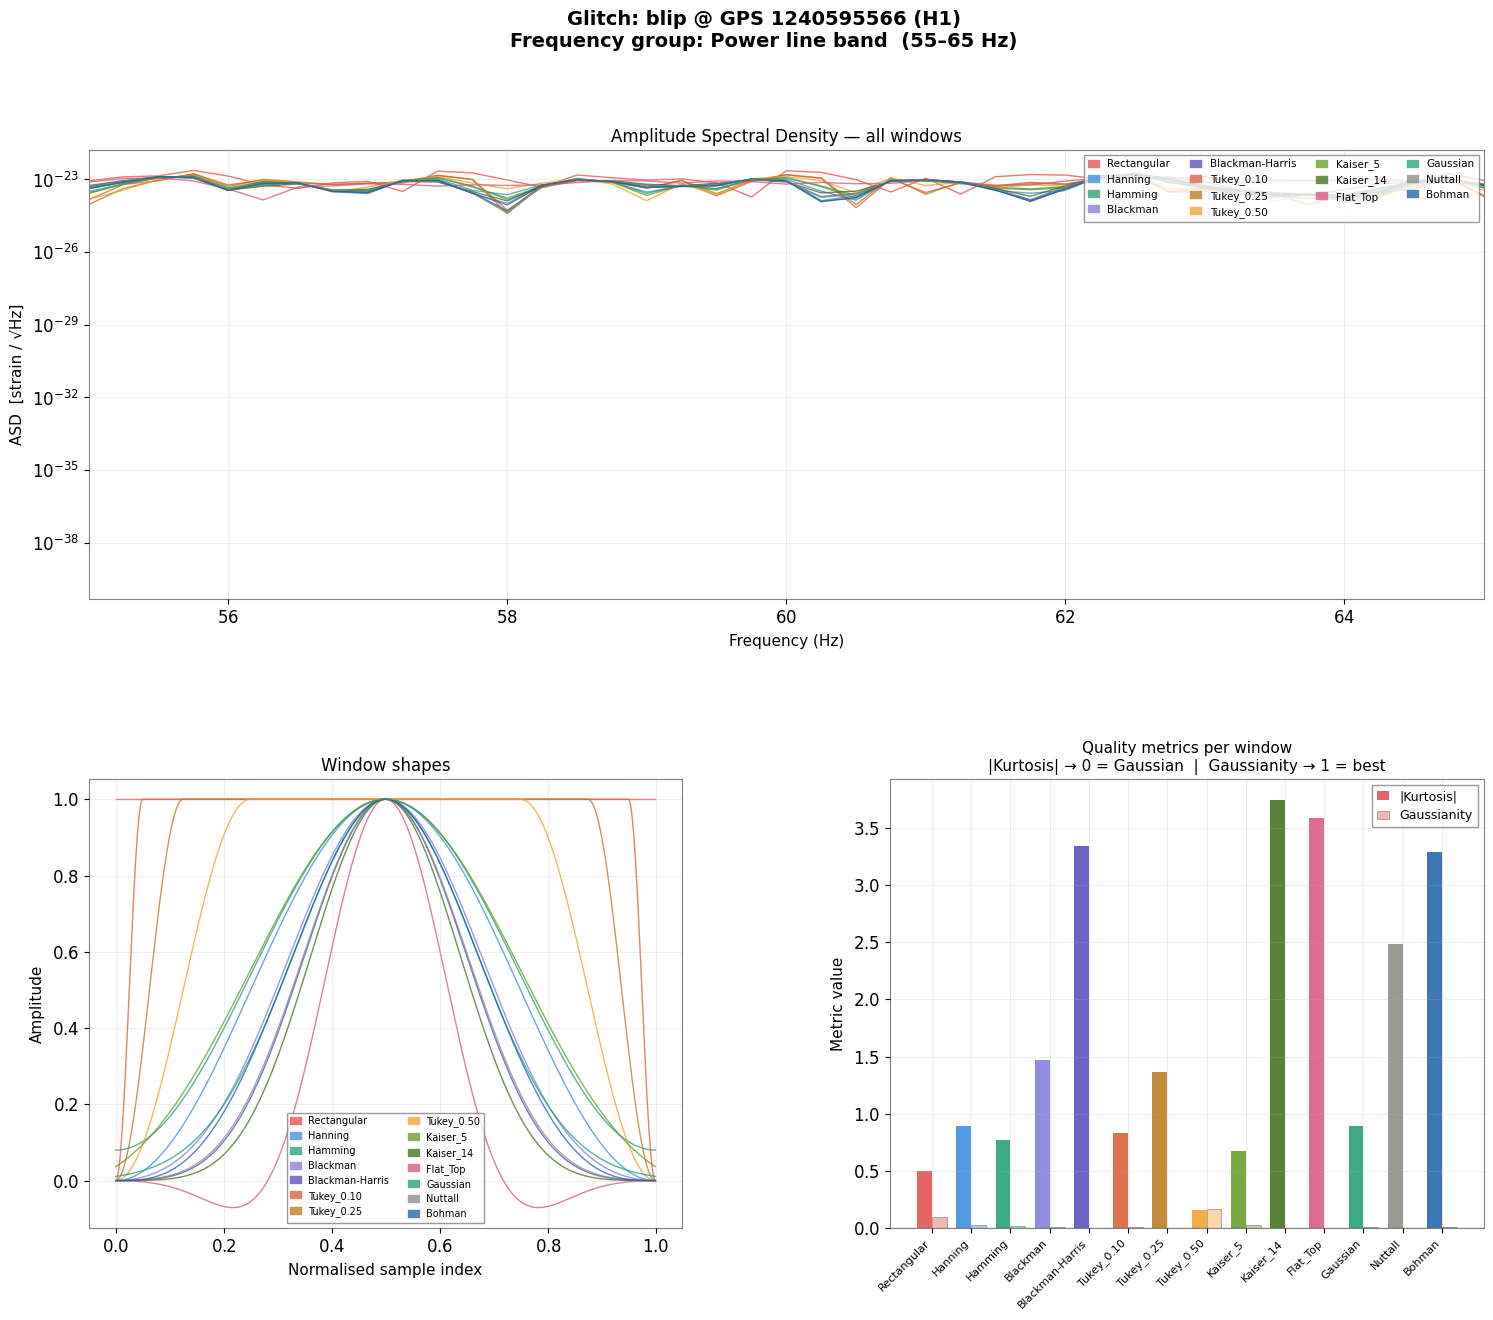

Saved: window_comparison.png


In [ ]:
#plotting
fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    f'{label_source}\n'
    f'Frequency group: {label}  ({flo}–{fhi} Hz)',
    fontsize=14, fontweight='bold', y=0.98
)

gs = gridspec.GridSpec(2, 2, figure=fig,
                       hspace=0.40, wspace=0.35)

ax_asd     = fig.add_subplot(gs[0, :])   # full top row — ASD
ax_windows = fig.add_subplot(gs[1, 0])   # bottom left  — window shapes
ax_metrics = fig.add_subplot(gs[1, 1])   # bottom right — metrics bar

names  = list(RESULTS.keys())
colors = [RESULTS[n]['color'] for n in names]

#ASD
for wname, res in RESULTS.items():
    ax_asd.semilogy(
        res['freqs'], res['asd'],
        color=res['color'], lw=1.0,
        alpha=0.75, label=wname
    )

ax_asd.set_xlim(flo, fhi)
ax_asd.set_xlabel('Frequency (Hz)', fontsize=11)
ax_asd.set_ylabel('ASD  [strain / √Hz]', fontsize=11)
ax_asd.set_title('Amplitude Spectral Density — all windows', fontsize=12)
ax_asd.legend(ncol=4, fontsize=7.5, loc='upper right')
ax_asd.grid(True, which='both', alpha=0.3)

#Window shapes
N_demo = 1024
t_demo = np.arange(N_demo) / N_demo

for wname, (wfn, _, wcolor) in WINDOWS.items():
    w = wfn(N_demo)
    ax_windows.plot(t_demo, w, color=wcolor, lw=1.0,
                    alpha=0.75, label=wname)

ax_windows.set_xlabel('Normalised sample index', fontsize=11)
ax_windows.set_ylabel('Amplitude', fontsize=11)
ax_windows.set_title('Window shapes', fontsize=12)
ax_windows.legend(ncol=2, fontsize=7, loc='lower center')
ax_windows.grid(True, alpha=0.3)

#Metrics bar chart — kurtosis (|kurt| → 0 = best)
kurt_vals = [abs(RESULTS[n]['metrics']['kurtosis']) for n in names]
gauss_vals = [RESULTS[n]['metrics']['gaussianity'] for n in names]

x      = np.arange(len(names))
width  = 0.38

bars_k = ax_metrics.bar(x - width/2, kurt_vals, width,
                         color=colors, alpha=0.85, label='|Kurtosis|')
bars_g = ax_metrics.bar(x + width/2, gauss_vals, width,
                         color=colors, alpha=0.40, label='Gaussianity',
                         edgecolor='black', linewidth=0.5)

ax_metrics.axhline(0, color='black', lw=0.8)
ax_metrics.set_xticks(x)
ax_metrics.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
ax_metrics.set_ylabel('Metric value', fontsize=11)
ax_metrics.set_title('Quality metrics per window\n'
                      '|Kurtosis| → 0 = Gaussian  |  Gaussianity → 1 = best',
                      fontsize=11)
ax_metrics.legend(fontsize=9)
ax_metrics.grid(True, axis='y', alpha=0.3)

plt.savefig('window_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: window_comparison.png")

In [ ]:
#analysis
print(f"\n{'Window':<22}  {'Gaussianity':>12}  {'|Kurtosis|':>10}  "
      f"{'Skewness':>9}  {'Rank'}")
print("-" * 65)

# Rank by |kurtosis| ascending (closer to 0 = more Gaussian residual)
ranked = sorted(RESULTS.items(),
                key=lambda x: abs(x[1]['metrics']['kurtosis']))

for rank, (wname, res) in enumerate(ranked, 1):
    m = res['metrics']
    print(f"  {wname:<22}  {m['gaussianity']:>12.4f}  "
          f"{abs(m['kurtosis']):>10.4f}  "
          f"{m['skewness']:>+9.4f}  #{rank}")

print(f"\nBest window for {label}: {ranked[0][0]}")
print(f"  → lowest |kurtosis| = {abs(ranked[0][1]['metrics']['kurtosis']):.4f}")
print(f"  → interpretation   : whitened residual most Gaussian under this window")


Window                   Gaussianity  |Kurtosis|   Skewness  Rank
-----------------------------------------------------------------
  Tukey_0.50                    0.1682      0.1573    +0.0918  #1
  Rectangular                   0.0982      0.4961    -0.0018  #2
  Kaiser_5                      0.0256      0.6761    +0.1838  #3
  Hamming                       0.0214      0.7741    +0.1919  #4
  Tukey_0.10                    0.0080      0.8283    -0.0759  #5
  Hanning                       0.0229      0.8882    -0.1247  #6
  Gaussian                      0.0116      0.8964    +0.1401  #7
  Tukey_0.25                    0.0031      1.3654    -0.0503  #8
  Blackman                      0.0088      1.4737    -0.0685  #9
  Nuttall                       0.0040      2.4850    +0.1093  #10
  Bohman                        0.0062      3.2891    -0.0418  #11
  Blackman-Harris               0.0037      3.3462    +0.1126  #12
  Flat_Top                      0.0025      3.5845    -0.0022  #13
  Kai